In [1]:
import pandas as pd
import numpy as np
import re
import unicodedata
# from sklearn.preprocessing import MultiLabelBinarizer
from collections import Counter
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel("../dataset/data_train_indobert_label.xlsx")

DATA INTEGRATION

In [4]:
df["text"] = (df["Nama Produk"] + " " + df["Deskripsi Produk"])

df = df.drop(columns=['Nama Produk', 'Deskripsi Produk'])

kolom_baru = ['text'] + [col for col in df.columns if col != 'text']
df = df[kolom_baru]

# df.to_csv("data_integration_train_label.csv", index=False, encoding='utf-8-sig', sep=';')
# print("File data_integration_train_label.csv berhasil disimpan")

print("\nPreview data:")
df[["text", "Jenis"]].head()


Preview data:


,text,Jenis
0,SANMOL FORTE 650 MG STRIP 4 TABLET Deskripsi:\...,"Analgesik, Antipiretik"
1,SANMOL 500 mg / SANMOL TABLET (HARGA/ STRIP) T...,"Analgesik, Antipiretik"
2,SANMOL 500 MG STRIP 4 TABLET Deskripsi:\nSanmo...,"Analgesik, Antipiretik"
3,ERPHAMOL FORTE 650 mg BOX Paracetamol-Obat Dem...,"Analgesik, Antipiretik"
4,PARACETAMOL TRIMAN 500 MG STRIP 10 KAPLET Desk...,"Analgesik, Antipiretik"


DATA CLEANING

In [5]:
def clean_text(text):
    text = str(text)
    text = unicodedata.normalize("NFKD", text)
    text = re.sub(r"[^\x00-\x7F]", " ", text)
    text = re.sub(r"[=]{2,}", " ", text)
    text = re.sub(r"[!#*~]{2,}", " ", text)
    text = re.sub(r"\n{2,}", "\n", text)
    text = re.sub(r"\s{2,}", " ", text)
    return text.strip()

In [6]:
print("Memulai pembersihan... Menampilkan maksimal 5 baris pertama yang berubah:\n")

preview_count = 0
preview_limit = 5 

for index, row in df.iterrows():
    text_original = row['text']
    text_cleaned = clean_text(text_original)

    df.loc[index, 'text'] = text_cleaned

    if text_original != text_cleaned and preview_count < preview_limit:
        removed_chars = set(text_original) - set(text_cleaned)
        chars_to_show = [char for char in removed_chars if not char.isspace()]
        
        if chars_to_show:
            sample_chars = chars_to_show[:3]
            print(f"Baris ke-{index}: Dihapus karakter seperti -> {', '.join(sample_chars)}")
        else:
            print(f"Baris ke-{index}: Dihapus spasi/baris baru berlebih")
            
        preview_count += 1

print("\n✅ Proses pembersihan seluruh data selesai.")
print("\nDataFrame setelah dibersihkan:")
print(df)

Memulai pembersihan... Menampilkan maksimal 5 baris pertama yang berubah:

Baris ke-0: Dihapus spasi/baris baru berlebih
Baris ke-1: Dihapus spasi/baris baru berlebih
Baris ke-2: Dihapus spasi/baris baru berlebih
Baris ke-4: Dihapus spasi/baris baru berlebih
Baris ke-7: Dihapus spasi/baris baru berlebih

✅ Proses pembersihan seluruh data selesai.

DataFrame setelah dibersihkan:
                                                   text  \
0     SANMOL FORTE 650 MG STRIP 4 TABLET Deskripsi:\...   
1     SANMOL 500 mg / SANMOL TABLET (HARGA/ STRIP) T...   
2     SANMOL 500 MG STRIP 4 TABLET Deskripsi:\nSanmo...   
3     ERPHAMOL FORTE 650 mg BOX Paracetamol-Obat Dem...   
4     PARACETAMOL TRIMAN 500 MG STRIP 10 KAPLET Desk...   
...                                                 ...   
8500  Promo Terbatas - Madu Hijau Menjaga Kesehatan ...   
8501  Madu Asmafas / Asma Dan Sesak Nafas / Napas Ma...   
8502  Diskon Ling Shen Yao Serbuk Obat Herbal Kanker...   
8503  TERLARIS " HERBAL ASAM 

In [7]:
# Hapus duplikat
before = len(df)
df = df.drop_duplicates(subset=["text"])
after = len(df)

print(f"Jumlah data sebelum: {before}, sesudah: {after}")

Jumlah data sebelum: 8505, sesudah: 4582


In [8]:
df.dropna(subset=['text'], inplace=True)
df = df[df['text'].str.lower() != 'nan']

# df.to_csv("data_cleaned_train_label.csv", index=False, encoding='utf-8-sig', sep=';')
# print("File data_cleaned_train_label.csv berhasil disimpan")

print(f"total data: {len(df)}")
all_labels = df["Jenis"].str.split(", ").explode() 
label_counts = Counter(all_labels)

print("\nJumlah data per label (multi-label):")
for label, count in label_counts.items():
    print(f"{label}: {count}")

total data: 4581

Jumlah data per label (multi-label):
Analgesik: 715
Antipiretik: 712
Herbal: 713
Antasida: 792
Ekspektoran: 785
Dekongestan: 789
Antiseptik: 726
Multivitamin: 786
Antidiare: 141


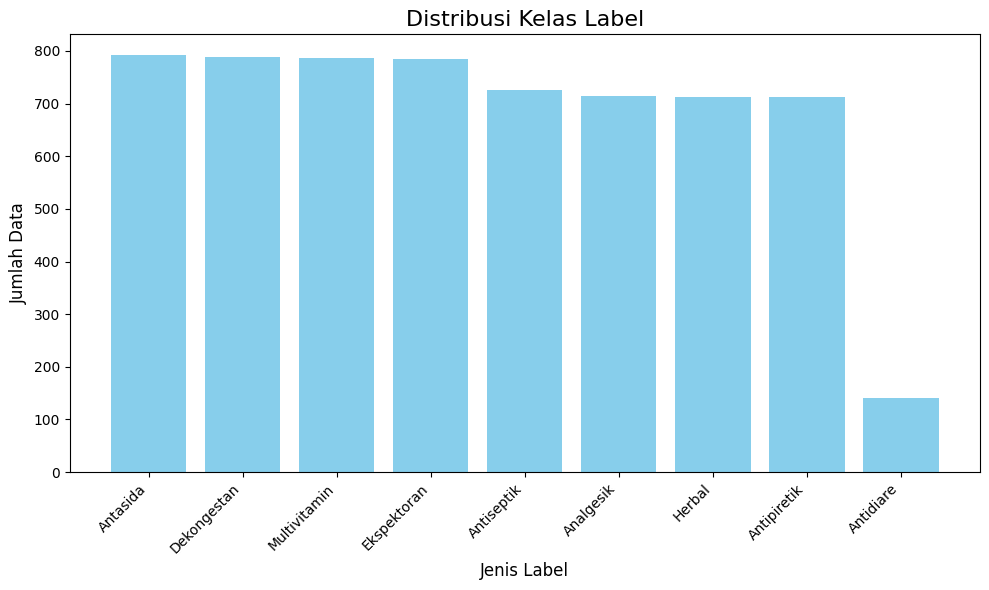

In [9]:
labels_df = pd.DataFrame.from_dict(label_counts, orient='index', columns=['count']).sort_values(by='count', ascending=False)
plt.figure(figsize=(10, 6))
bars = plt.bar(labels_df.index, labels_df['count'], color='skyblue')
plt.title('Distribusi Kelas Label', fontsize=16)
plt.xlabel('Jenis Label', fontsize=12)
plt.ylabel('Jumlah Data', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig('../dataset/distribusi_kelas_train.png')

In [10]:
df.to_csv("../dataset/preprocessed_indobert_data_train_label.csv", index=False, sep=';')